# Cell 0 — Kiểm tra GPU

In [1]:
import torch, os, sys

ROOT = r"D:\Documents\KimTin\BienSo Detection"
os.chdir(ROOT)

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("ROOT:", os.getcwd())

Python: d:\Documents\KimTin\BienSo Detection\.venv\Scripts\python.exe
Torch: 2.11.0+cu126
CUDA: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
ROOT: D:\Documents\KimTin\BienSo Detection


# Cell 1 — Import thư viện

In [2]:
import os, glob, yaml, shutil, random, cv2, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm
from ultralytics import YOLO

ROOT = Path(r"D:\Documents\KimTin\BienSo Detection")
DATA = ROOT / "dataset"
TRAIN, VALID, TEST = DATA / "train", DATA / "valid", DATA / "test"
YAML = DATA / "data.yaml"
RUNS = ROOT / "runs"
WEIGHTS = ROOT / "weights"

os.chdir(ROOT)
print(ROOT)

D:\Documents\KimTin\BienSo Detection


# Cell 2 — Load dataset

In [ ]:
import zipfile, shutil
DATA = Path(r"D:\Documents\KimTin\BienSo Detection\dataset")
splits = {"train": DATA/"train", "val": DATA/"valid", "valid": DATA/"valid", "validation": DATA/"valid", "test": DATA/"test"}
exts = {".jpg",".jpeg",".png",".bmp",".webp"}

for z in DATA.glob("*.zip"):
    with zipfile.ZipFile(z) as f:
        f.extractall(DATA/z.stem)

pairs = []
for img_dir in DATA.rglob("images"):
    imgs = [p for p in img_dir.iterdir() if p.suffix.lower() in exts]
    lab_dir = img_dir.parent/"labels"
    if imgs and lab_dir.exists():
        pairs.append((img_dir.parent.name.lower(), img_dir, lab_dir, len(imgs), len(list(lab_dir.glob("*.txt")))))

print("FOUND:")
for x in pairs:
    print(x)

for s, img_dir, lab_dir, _, _ in pairs:
    if s in splits:
        out = splits[s]
        (out/"images").mkdir(parents=True, exist_ok=True)
        (out/"labels").mkdir(parents=True, exist_ok=True)
        for p in img_dir.iterdir():
            if p.suffix.lower() in exts:
                shutil.copy2(p, out/"images"/p.name)
        for p in lab_dir.glob("*.txt"):
            shutil.copy2(p, out/"labels"/p.name)

yaml_text = "path: D:/Documents/KimTin/BienSo Detection/dataset\ntrain: train/images\nval: valid/images\ntest: test/images\n\nnc: 1\nnames: ['Bien-so']\n"
(DATA/"data.yaml").write_text(yaml_text, encoding="utf-8")

for s in ["train","valid","test"]:
    p = DATA/s
    print(s, len(list((p/"images").glob("*"))), len(list((p/"labels").glob("*.txt"))))

print((DATA/"data.yaml").read_text(encoding="utf-8"))

FOUND:
('test', WindowsPath('D:/Documents/KimTin/BienSo Detection/dataset/splits/splits/test/images'), WindowsPath('D:/Documents/KimTin/BienSo Detection/dataset/splits/splits/test/labels'), 73, 73)
('train', WindowsPath('D:/Documents/KimTin/BienSo Detection/dataset/splits/splits/train/images'), WindowsPath('D:/Documents/KimTin/BienSo Detection/dataset/splits/splits/train/labels'), 2036, 2036)
('val', WindowsPath('D:/Documents/KimTin/BienSo Detection/dataset/splits/splits/val/images'), WindowsPath('D:/Documents/KimTin/BienSo Detection/dataset/splits/splits/val/labels'), 146, 146)
train 2036 2036
valid 146 146
test 73 73
path: D:/Documents/KimTin/BienSo Detection/dataset
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['Bien-so']



# Cell 3 — EDA dataset

In [9]:
splits = {"train": TRAIN, "valid": VALID, "test": TEST}
rows, boxes = [], []

for sp, root in splits.items():
    for im in (root/"images").glob("*"):
        if im.suffix.lower() not in [".jpg",".jpeg",".png",".bmp",".webp"]:
            continue
        img = cv2.imread(str(im))
        h, w = img.shape[:2]
        lb = root/"labels"/f"{im.stem}.txt"
        n = 0
        if lb.exists():
            for line in lb.read_text().splitlines():
                a = line.split()
                if len(a) == 5:
                    c, x, y, bw, bh = map(float, a)
                    boxes.append([sp, im.name, int(c), bw*w, bh*h, bw, bh])
                    n += 1
        rows.append([sp, im.name, w, h, n])

df_img = pd.DataFrame(rows, columns=["split","image","w","h","bbox"])
df_box = pd.DataFrame(boxes, columns=["split","image","class","box_w","box_h","box_wn","box_hn"])

print(df_img.groupby("split").agg(images=("image","count"), bboxes=("bbox","sum")))
display(df_img.head())
display(df_box.head())

       images  bboxes
split                
test       73      94
train    2036    2713
valid     146     191


,split,image,w,h,bbox
0,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3.jpg,194,259,1
1,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3_aug0.jpg,194,259,1
2,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3_aug1.jpg,194,259,1
3,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3_aug2.jpg,194,259,1
4,train,102_jpg.rf.jKhspnMQrDPGovBKWELd.jpg,168,300,2


,split,image,class,box_w,box_h,box_wn,box_hn
0,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3.jpg,0,17.202950,24.837064,0.088675,0.095896
1,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3_aug0.jpg,0,18.012900,26.156928,0.092850,0.100992
2,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3_aug1.jpg,0,17.528482,25.102280,0.090353,0.096920
3,train,101_jpg.rf.kQBFXAPPdQUevwheU1F3_aug2.jpg,0,17.423916,24.201996,0.089814,0.093444
4,train,102_jpg.rf.jKhspnMQrDPGovBKWELd.jpg,0,31.064040,27.311100,0.184905,0.091037


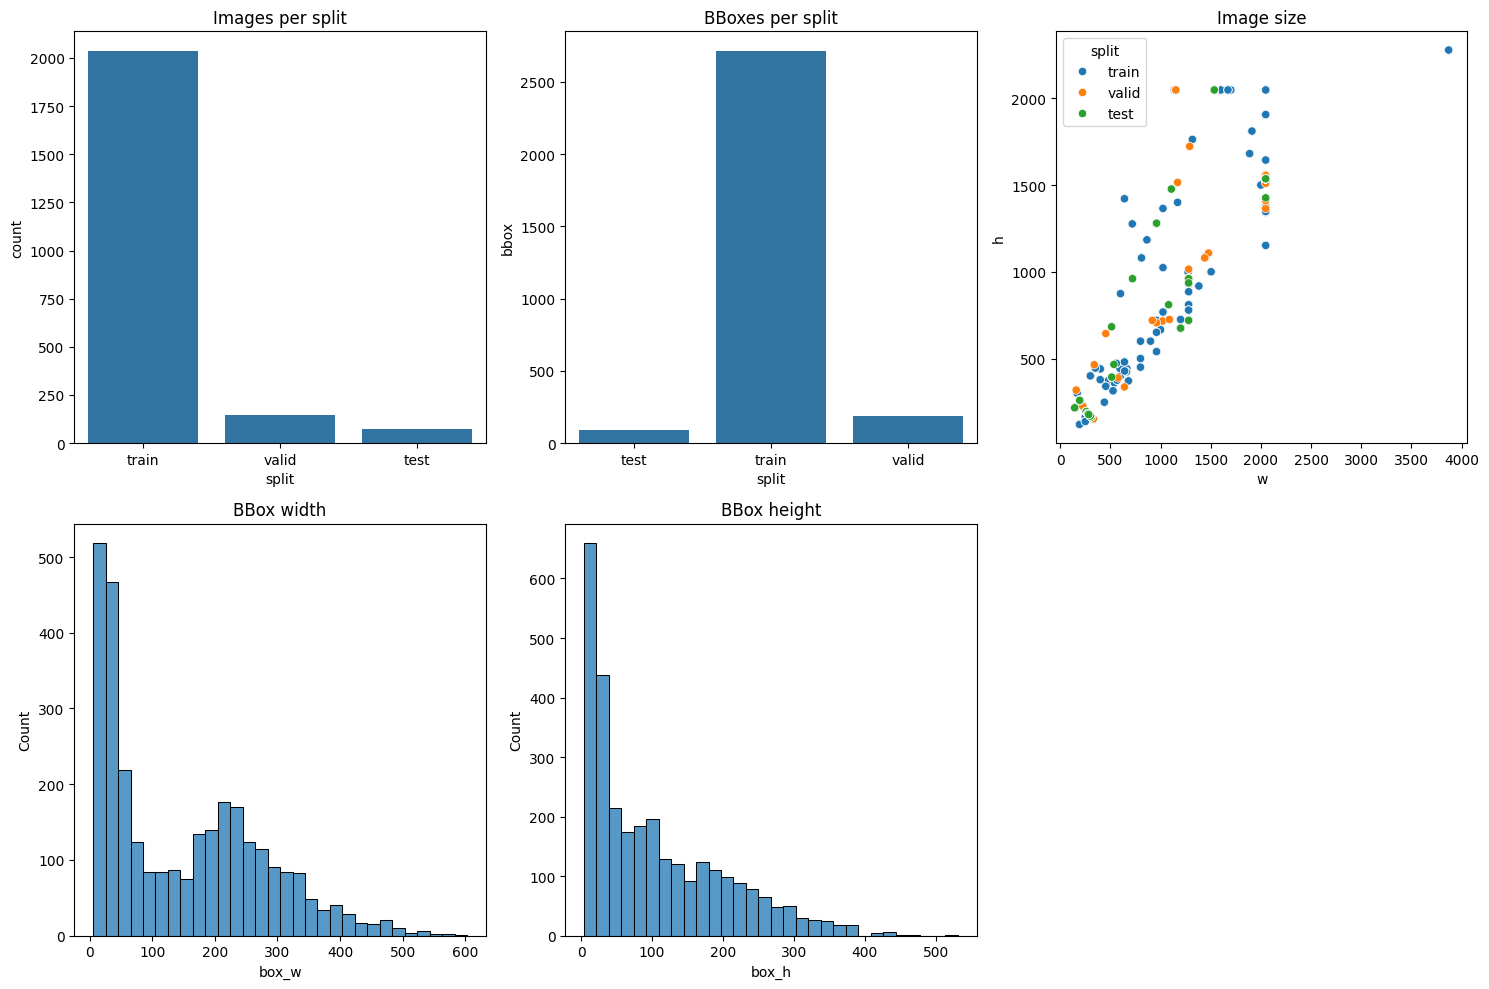

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.countplot(data=df_img, x="split")
plt.title("Images per split")

plt.subplot(2, 3, 2)
sns.barplot(data=df_img.groupby("split", as_index=False)["bbox"].sum(), x="split", y="bbox")
plt.title("BBoxes per split")

plt.subplot(2, 3, 3)
sns.scatterplot(data=df_img, x="w", y="h", hue="split")
plt.title("Image size")

plt.subplot(2, 3, 4)
sns.histplot(df_box["box_w"], bins=30)
plt.title("BBox width")

plt.subplot(2, 3, 5)
sns.histplot(df_box["box_h"], bins=30)
plt.title("BBox height")

plt.tight_layout()
plt.show()

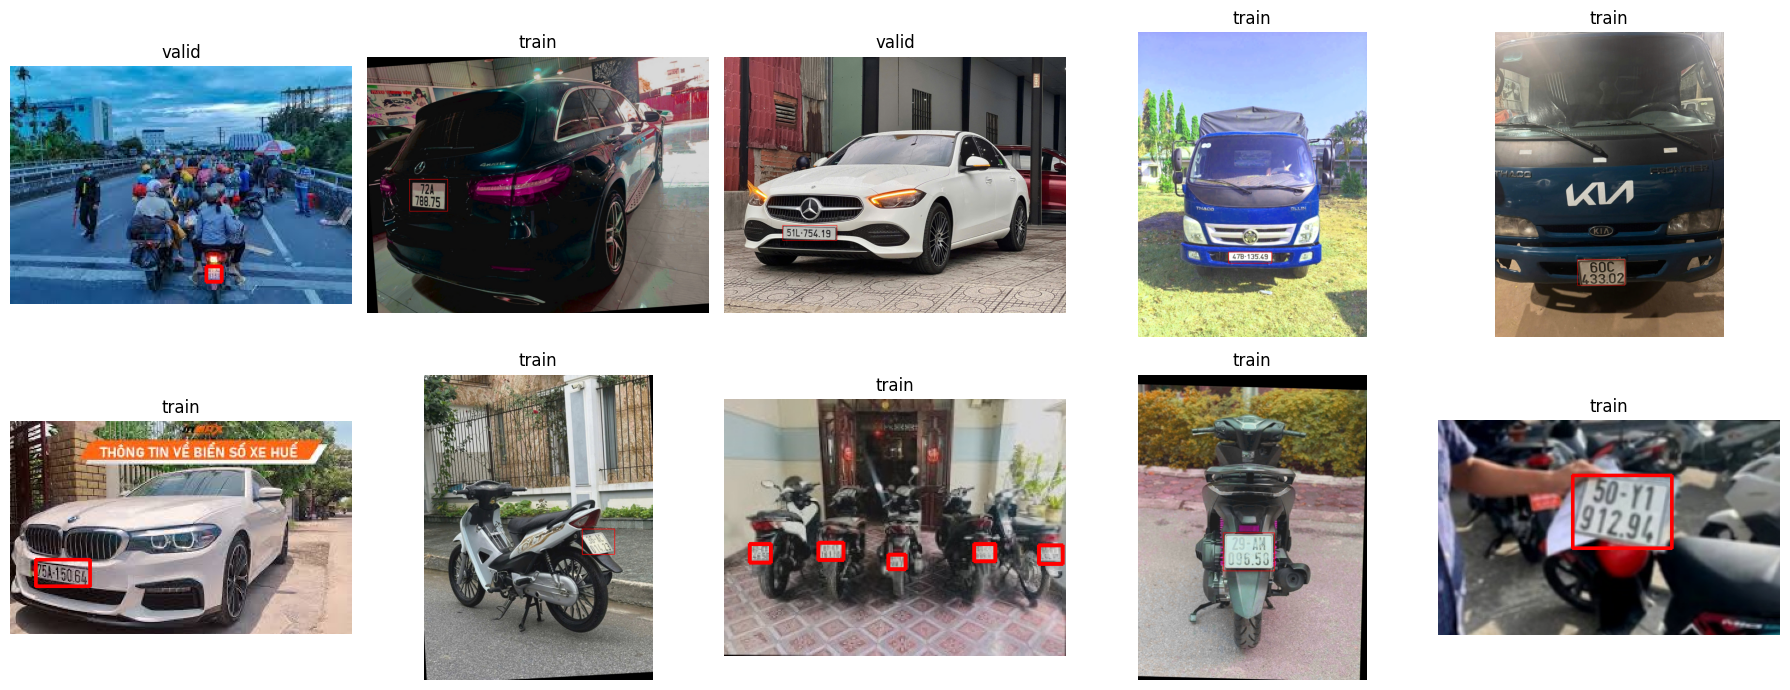

In [11]:
sample = df_img.sample(min(10, len(df_img)), random_state=42)
fig, ax = plt.subplots(2, 5, figsize=(18, 7))
ax = ax.ravel()

for i, r in enumerate(sample.itertuples()):
    root = splits[r.split]
    im = root/"images"/r.image
    lb = root/"labels"/f"{Path(r.image).stem}.txt"
    img = cv2.cvtColor(cv2.imread(str(im)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if lb.exists():
        for line in lb.read_text().splitlines():
            c, x, y, bw, bh = map(float, line.split())
            x1, y1 = int((x-bw/2)*w), int((y-bh/2)*h)
            x2, y2 = int((x+bw/2)*w), int((y+bh/2)*h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    ax[i].imshow(img)
    ax[i].set_title(r.split)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

# Cell 4 — Data augmentation config

In [13]:
AUG = dict(
    hsv_h=0.015,
    hsv_s=0.45,
    hsv_v=0.35,
    degrees=5,
    translate=0.08,
    scale=0.35,
    shear=1.0,
    perspective=0.0005,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.8,
    mixup=0.05,
    copy_paste=0.0,
    erasing=0.15,
    close_mosaic=10
)

aug_count = sum("_aug" in p.stem for p in (TRAIN/"images").glob("*"))
print("train images:", len(list((TRAIN/"images").glob("*"))))
print("augmented images:", aug_count)
display(pd.DataFrame([AUG]).T.rename(columns={0:"value"}))

train images: 2036
augmented images: 1527


,value
hsv_h,0.0150
hsv_s,0.4500
hsv_v,0.3500
degrees,5.0000
translate,0.0800
scale,0.3500
shear,1.0000
perspective,0.0005
flipud,0.0000
fliplr,0.5000


# Cell 5 — Hyperparameters

In [15]:
MODEL_NAME = "yolo26n.pt"

HP = dict(
    data=str(YAML),
    epochs=120,
    imgsz=640,
    batch=8,
    workers=0,
    device=0,
    patience=25,
    optimizer="auto",
    lr0=0.002,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,
    weight_decay=0.0005,
    project=str(RUNS),
    name="yolo26_biensao_v1",
    exist_ok=True,
    pretrained=True,
    val=True,
    plots=True,
    save=True,
    **AUG
)

display(pd.DataFrame([HP]).T.rename(columns={0:"value"}))

,value
data,D:\Documents\KimTin\BienSo Detection\dataset\d...
epochs,120
imgsz,640
batch,8
workers,0
device,0
patience,25
optimizer,auto
lr0,0.002
lrf,0.01


# Cell 6 — Huấn luyện YOLOv26 pretrained

In [16]:
model = YOLO(MODEL_NAME)
results = model.train(**HP)

Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Documents\KimTin\BienSo Detection\dataset\data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.15, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.35, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=yolo26_biensao_v1, nbs=64, nms=False, opset=None, optimi

# Cell 7 — Đánh giá

In [17]:
RUN_DIR = RUNS / "yolo26_biensao_v1"
BEST = RUN_DIR / "weights" / "best.pt"

df_res = pd.read_csv(RUN_DIR / "results.csv")
df_res.columns = df_res.columns.str.strip()

display(df_res.tail())

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
108,109,10485.7,0.77786,0.30686,0.00368,0.97759,0.92670,0.96713,0.68687,1.05743,0.38766,0.00637,0.000068,0.000068,0.000068
109,110,10580.1,0.77555,0.30887,0.00378,0.96792,0.92670,0.96622,0.67675,1.06461,0.39325,0.00644,0.000061,0.000061,0.000061
110,111,10669.7,0.62240,0.20355,0.00327,0.96832,0.92670,0.96489,0.67832,1.07064,0.40058,0.00642,0.000054,0.000054,0.000054
111,112,10761.0,0.62404,0.19944,0.00322,0.97019,0.92670,0.96619,0.68335,1.06207,0.39836,0.00640,0.000047,0.000047,0.000047
112,113,10854.0,0.62724,0.20285,0.00329,0.97261,0.92972,0.96620,0.68013,1.07196,0.40714,0.00644,0.000042,0.000042,0.000042


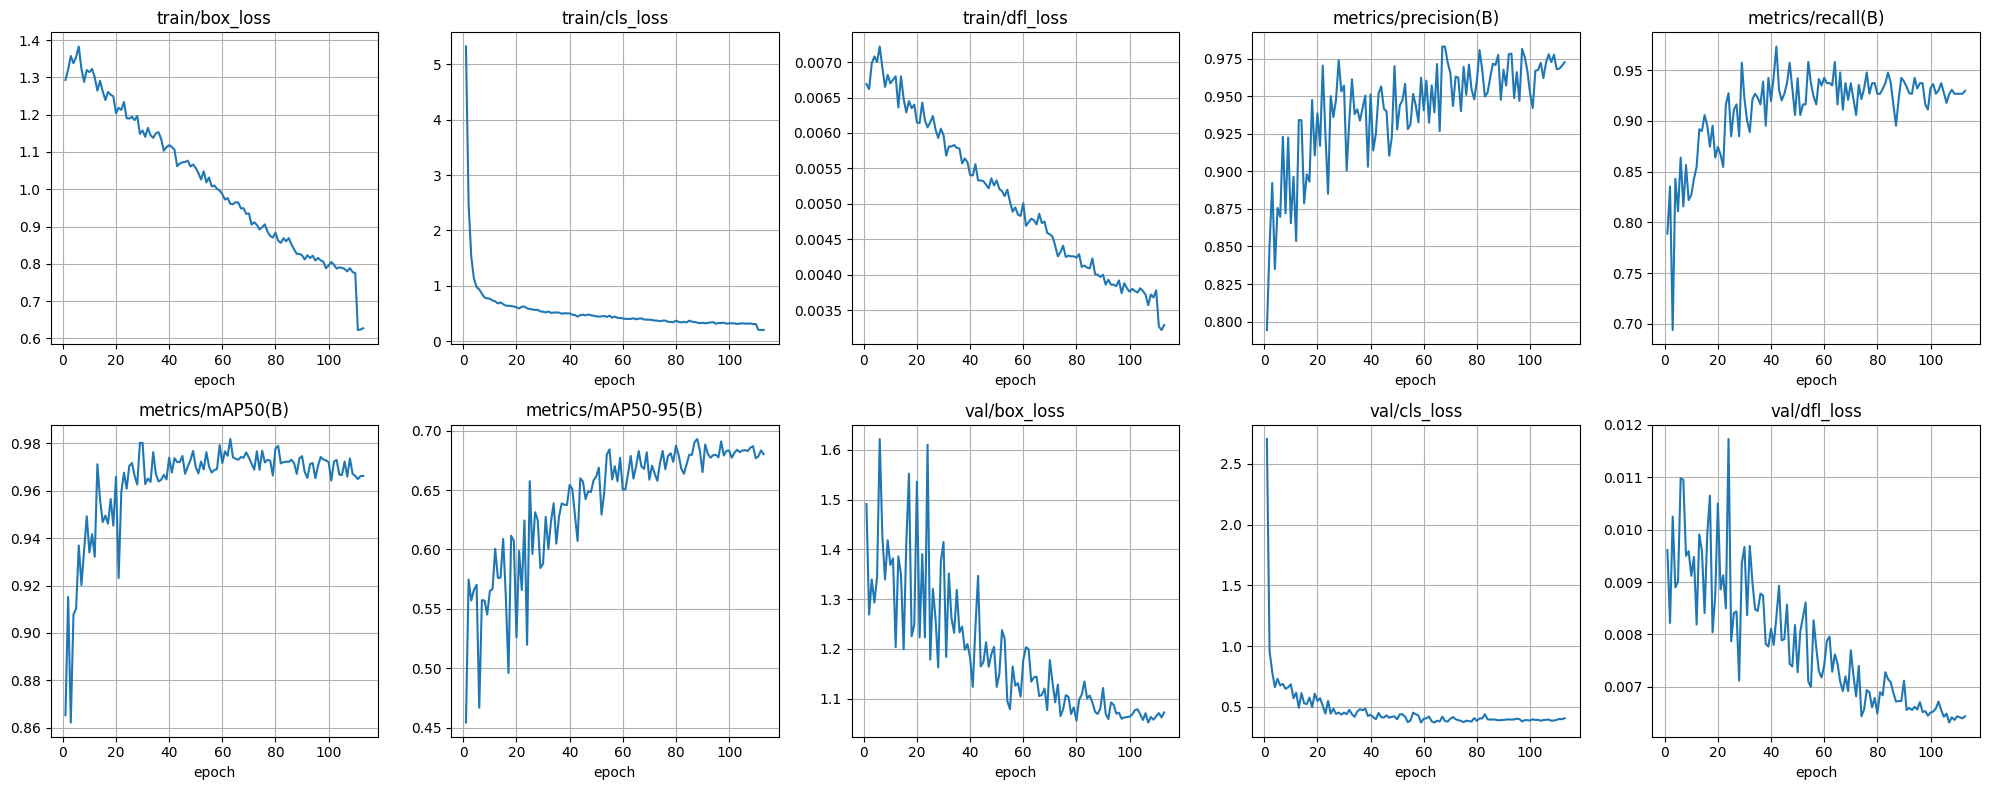

In [20]:
import matplotlib.pyplot as plt

cols = [c for c in df_res.columns if "loss" in c or "mAP50" in c or "precision" in c or "recall" in c]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()  

for i, c in enumerate(cols):
    if i < len(axes):
        axes[i].plot(df_res["epoch"], df_res[c])
        axes[i].set_title(c)
        axes[i].set_xlabel("epoch")
        axes[i].grid(True)

plt.tight_layout()
plt.show()

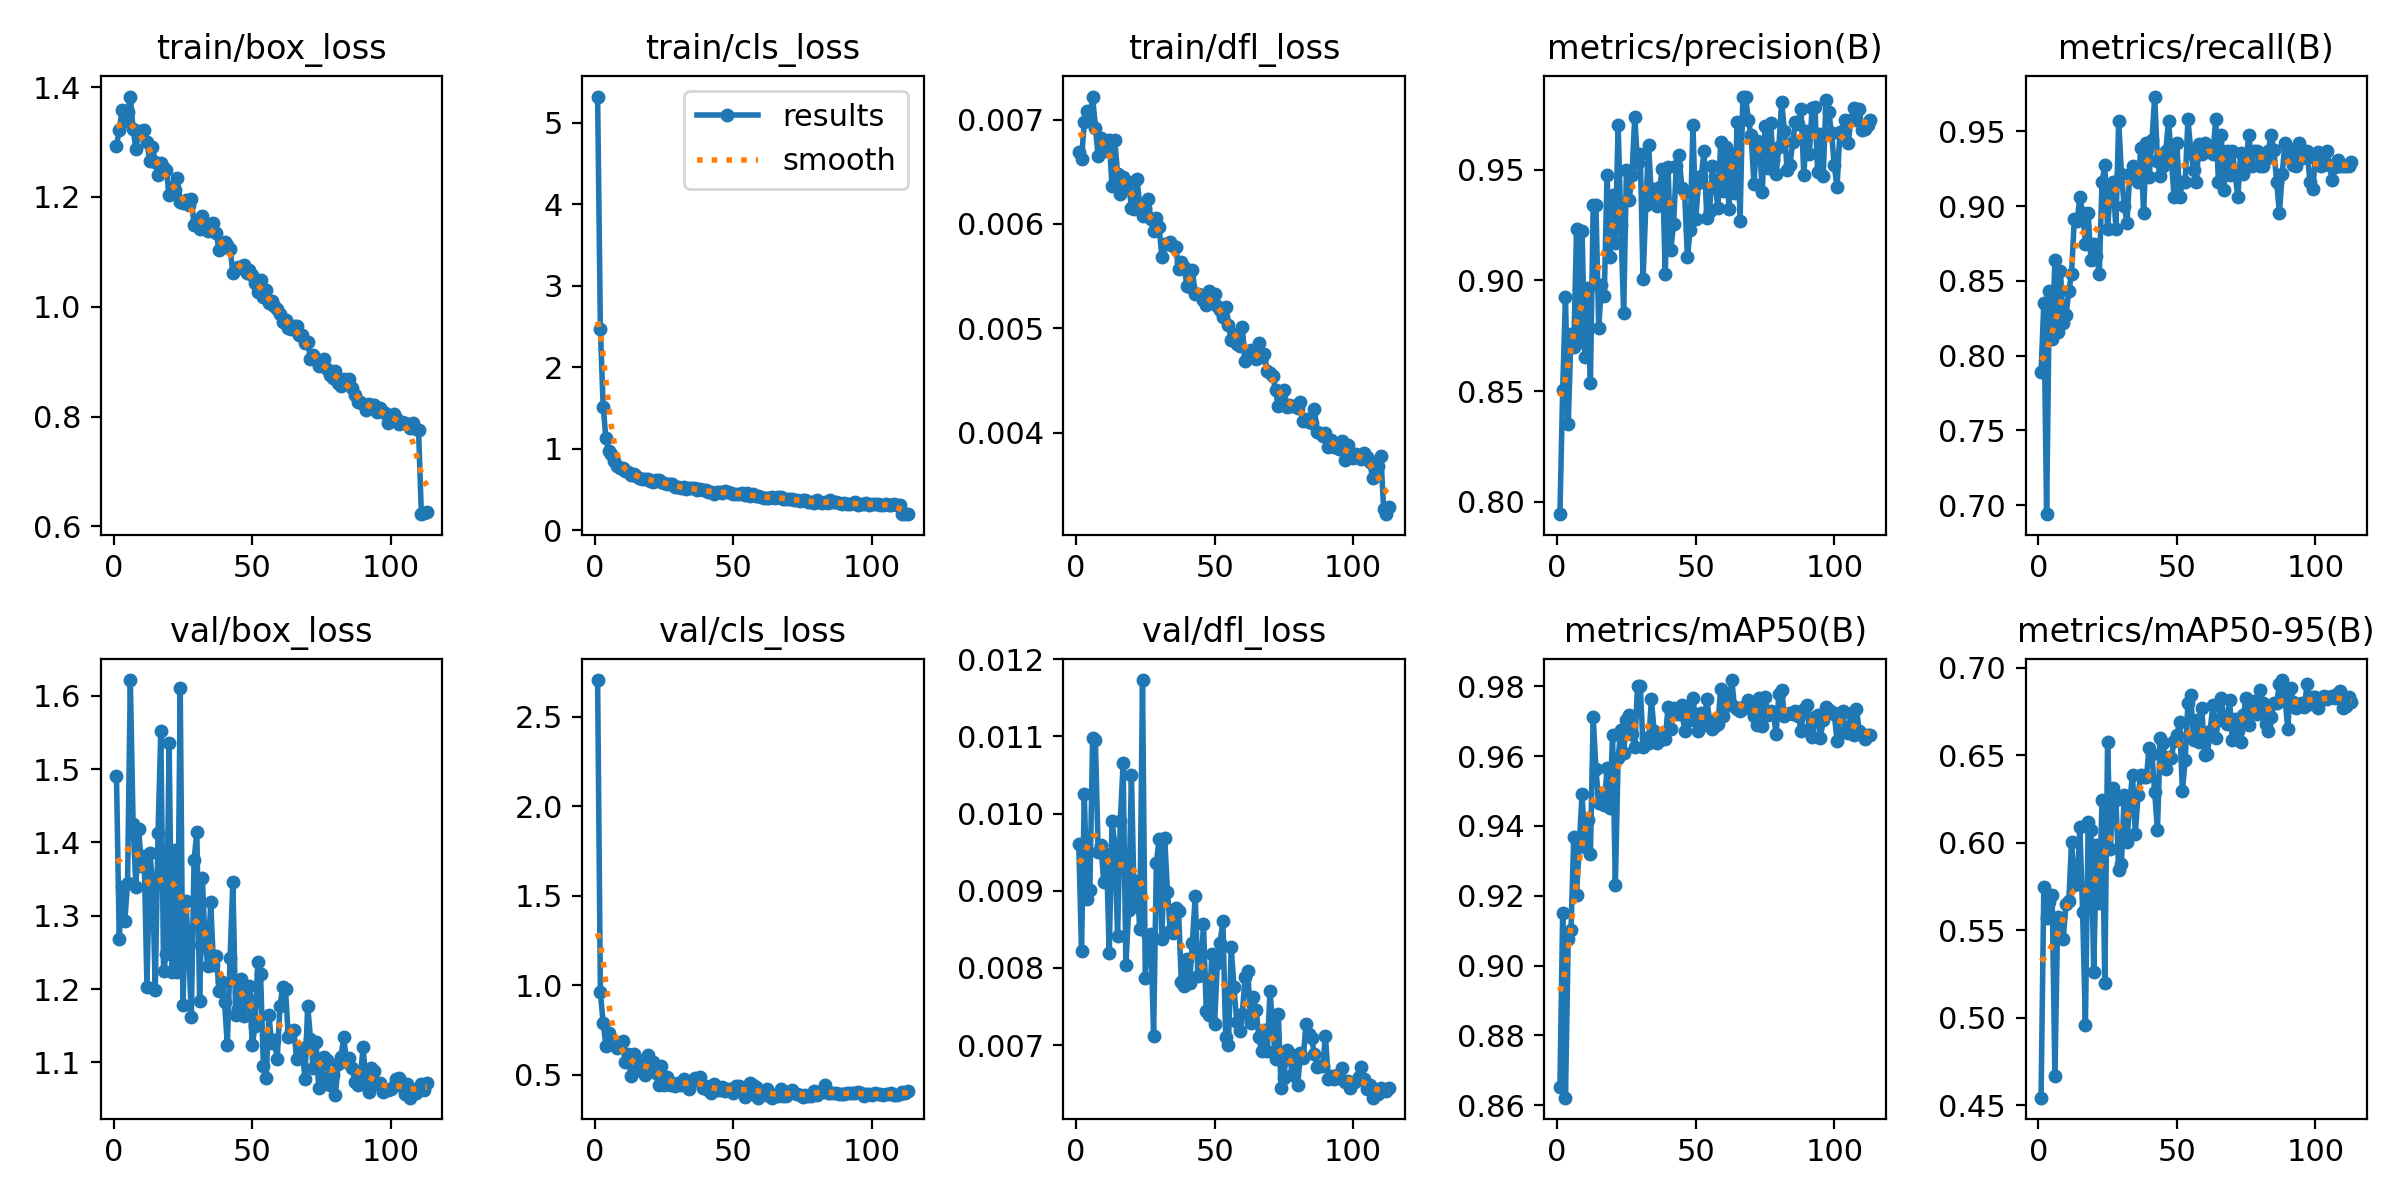

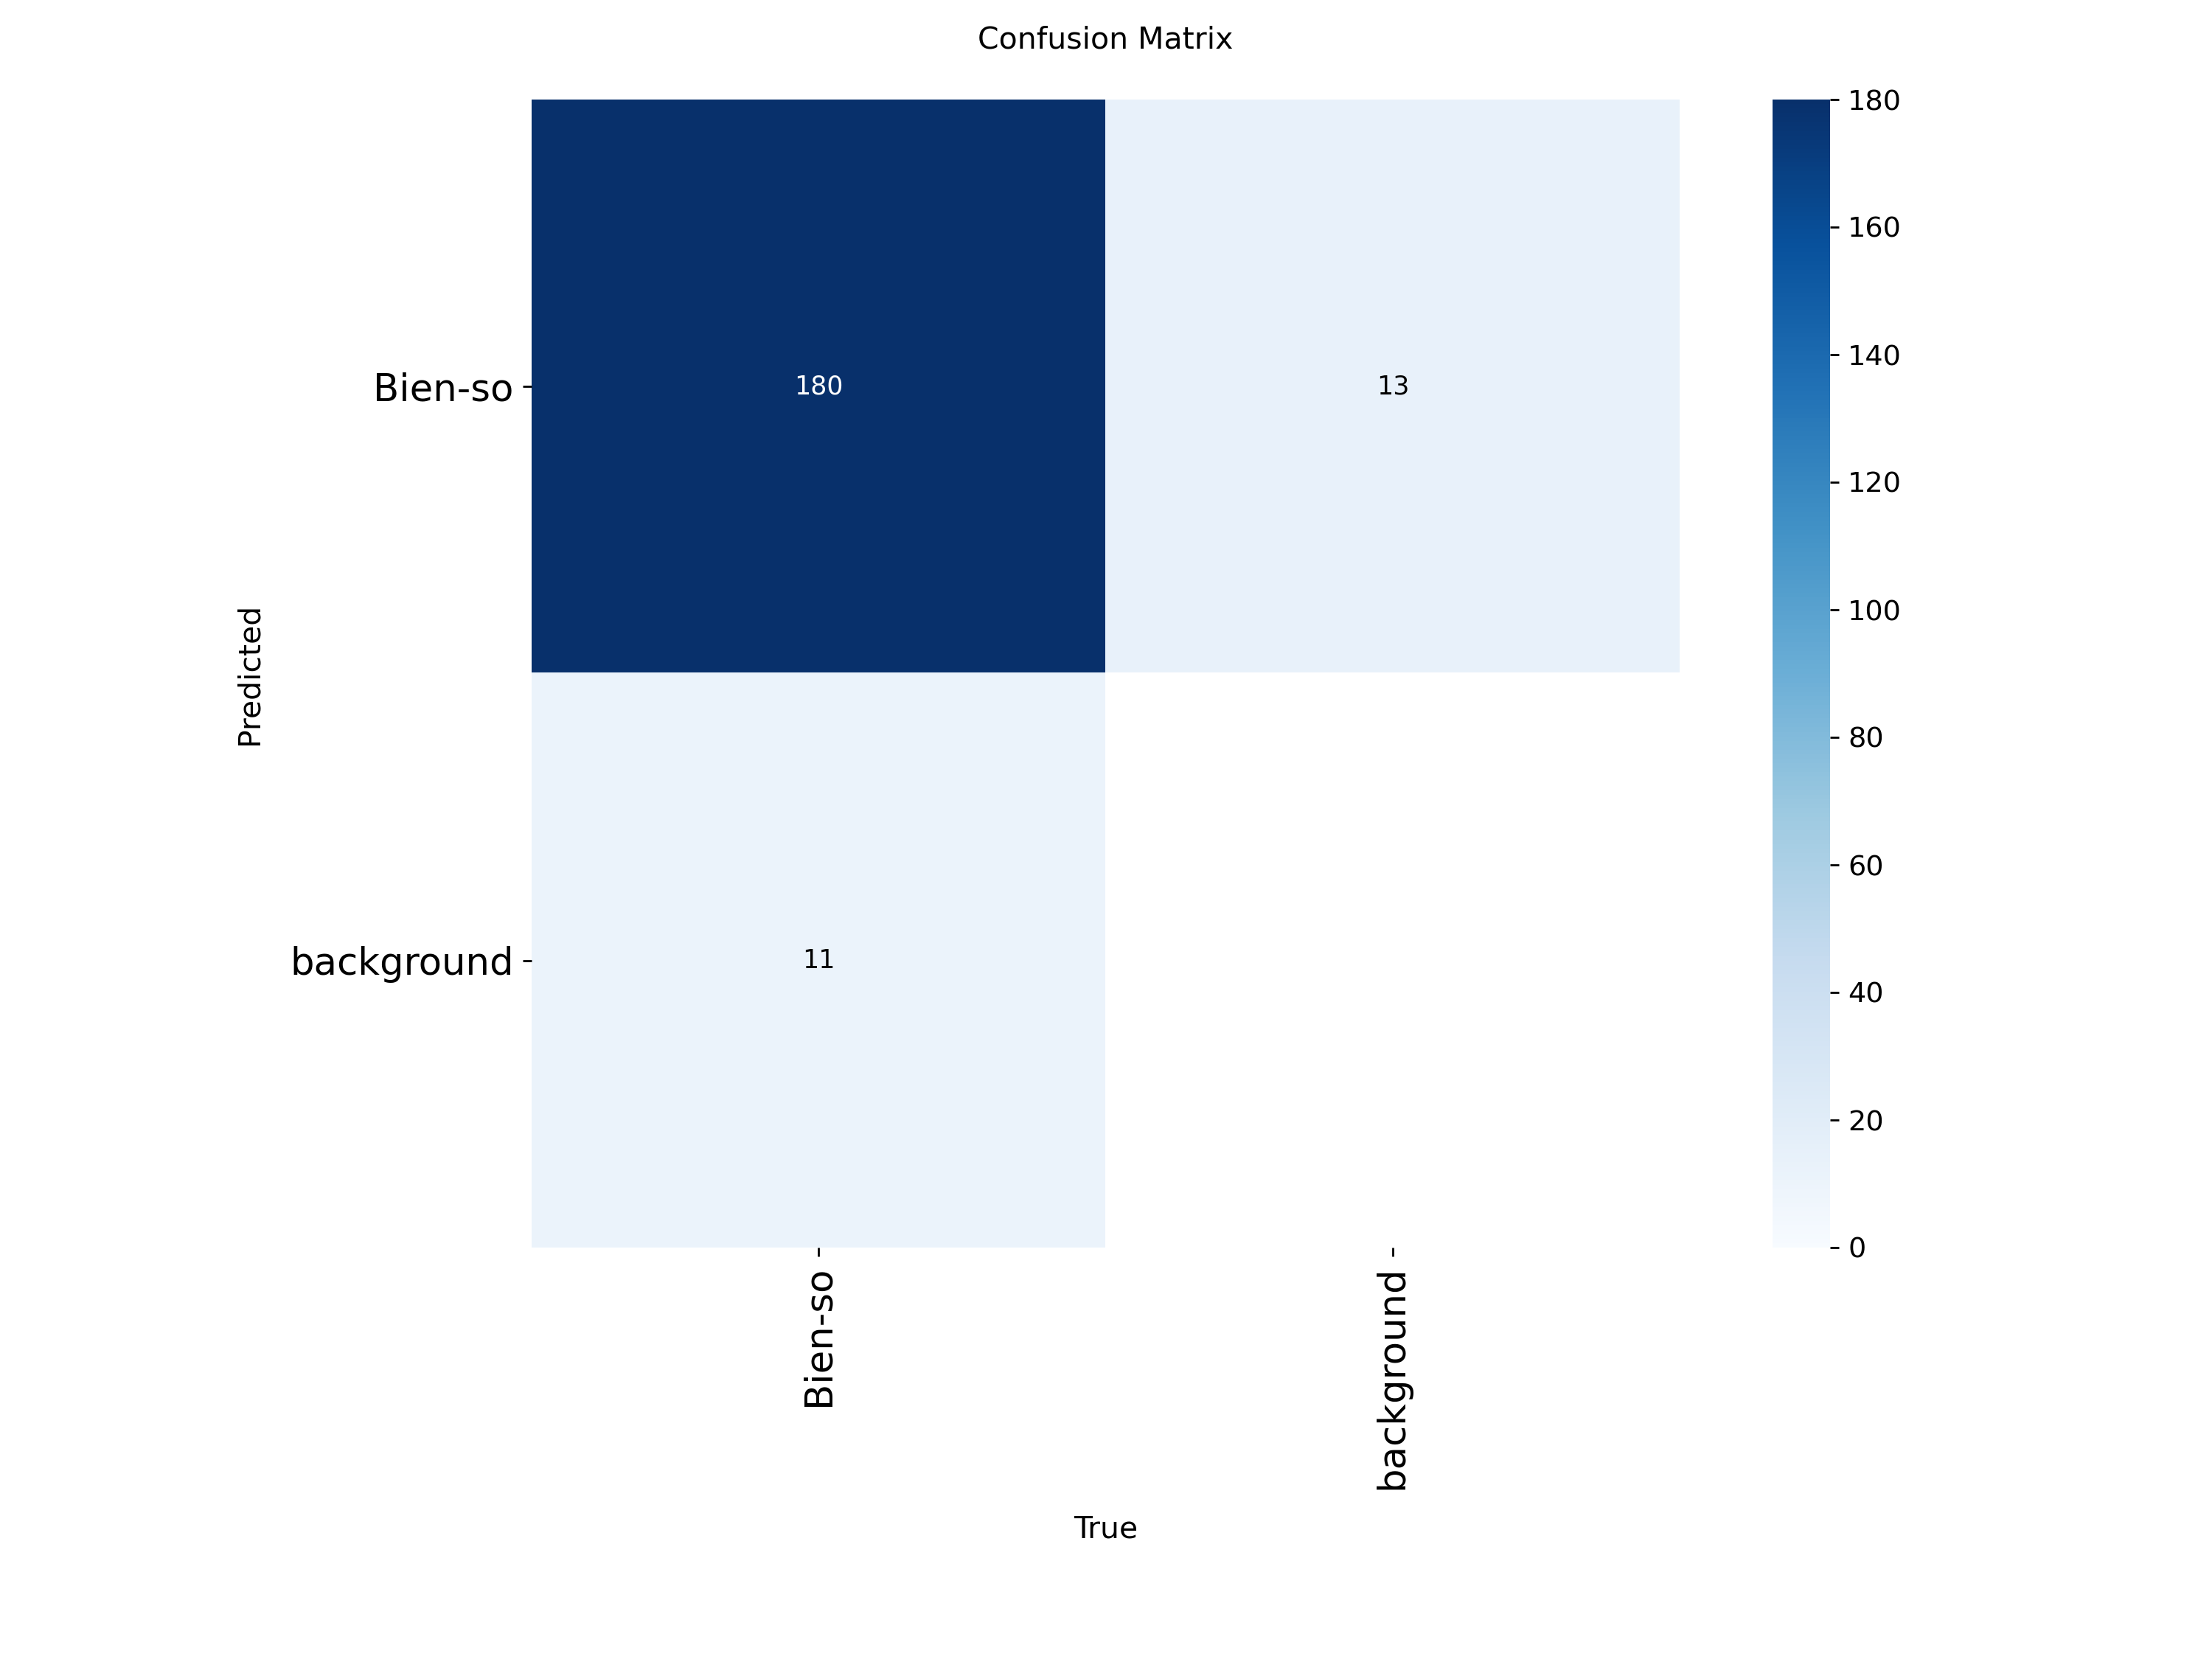

In [28]:
from IPython.display import Image, display

for f in ["results.png", "confusion_matrix.png", "PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png"]:
    p = RUN_DIR / f
    if p.exists():
        display(Image(filename=str(p)))

In [22]:
best_model = YOLO(str(BEST))

val_metrics = best_model.val(data=str(YAML), split="val", imgsz=640, batch=8, device=0)
test_metrics = best_model.val(data=str(YAML), split="test", imgsz=640, batch=8, device=0)

print("VAL :", val_metrics.box.mp, val_metrics.box.mr, val_metrics.box.map50, val_metrics.box.map)
print("TEST:", test_metrics.box.mp, test_metrics.box.mr, test_metrics.box.map50, test_metrics.box.map)

Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 149.4245.0 MB/s, size: 192.1 KB)
val: Scanning D:\Documents\KimTin\BienSo Detection\dataset\valid\labels.cache... 146 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 146/146  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.9it/s 6.6s<0.1s
                   all        146        191      0.967      0.928      0.967       0.69
Speed: 2.3ms preprocess, 10.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\Acer\runs\detect\val
Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 153.2298.9 MB/s, size: 175.1 KB)
val: Scanning D:\Documents\KimTin\BienSo 

# Cell 8 — Lưu mô hình tốt nhất

In [29]:
import json

RUN_DIR = RUNS / "yolo26_biensao_v1"
BEST = RUN_DIR / "weights" / "best.pt"
LAST = RUN_DIR / "weights" / "last.pt"

WEIGHTS.mkdir(exist_ok=True)

OUT_BEST = WEIGHTS / "yolo26_biensao_best.pt"
OUT_LAST = WEIGHTS / "yolo26_biensao_last.pt"

shutil.copy2(BEST, OUT_BEST)
if LAST.exists():
    shutil.copy2(LAST, OUT_LAST)

metrics = {
    "val": {
        "precision": float(val_metrics.box.mp),
        "recall": float(val_metrics.box.mr),
        "map50": float(val_metrics.box.map50),
        "map50_95": float(val_metrics.box.map)
    },
    "test": {
        "precision": float(test_metrics.box.mp),
        "recall": float(test_metrics.box.mr),
        "map50": float(test_metrics.box.map50),
        "map50_95": float(test_metrics.box.map)
    }
}

(WEIGHTS / "metrics.json").write_text(json.dumps(metrics, indent=4), encoding="utf-8")

print(OUT_BEST)
print(OUT_LAST)
print(WEIGHTS / "metrics.json")

D:\Documents\KimTin\BienSo Detection\weights\yolo26_biensao_best.pt
D:\Documents\KimTin\BienSo Detection\weights\yolo26_biensao_last.pt
D:\Documents\KimTin\BienSo Detection\weights\metrics.json
